# 주택 가격 예측하기!

메인퀘스트에 오신 것을 환영합니다!

이번 퀘스트의 목표는 여러 특성들을 종합적으로 고려하여 가장 주택 가격을 잘 예측하는 회귀모델을 만드는 것입니다.

- 예측할 값(y): SalePrice
- 평가지표: RMSE

퀘스트 진행 방식:

1. Code 란에서 테스트 노트북을 Copy&Edit 하여 작업!
2. 테스트 노트북을 submit 하여 리더보드에 정상적으로 등록되는지 확인하기
3. 자유롭게 모델을 발전시켜 좋은 성적 거두기!
4. 정상적으로 submit하고, 다음 구글폼에 이름/노트북주소/닉네임 등록!!!
- https://docs.google.com/forms/d/e/1FAIpQLSc0kXVZ9PRLbjsxBysCSSYLDiU4Hd9DLTvFrCFep4HLZLbL8w/viewform?usp=header

예시 형식:
~~~
Id,SalePrice
1461,169000.1
1462,187724.1233
1463,175221
etc.
~~~

### 데이터 확인 및 불러오기

In [1]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
train_df = pd.read_csv('./train.csv')
test_df = pd.read_csv('./test.csv')

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1168 entries, 0 to 1167
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    950 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          70 non-null     object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64  
 18  OverallC

특성이 너무 많습니다! 어떻게 하면 좋을까요?

참고로 각각의 특성은 다음을 나타냅니다.

| 변수명               | 설명 (한국어)                         |
| ----------------- | -------------------------------- |
| **SalePrice**     | 주택의 판매 가격(달러). 예측해야 하는 타겟 변수     |
| **MSSubClass**    | 건물 등급(건물 종류 분류)                  |
| **MSZoning**      | 토지 용도 구분(일반적인 구역 분류)             |
| **LotFrontage**   | 도로에 접한 토지 길이 (피트 단위)             |
| **LotArea**       | 토지 면적 (평방 피트)                    |
| **Street**        | 도로 접근 방식                         |
| **Alley**         | 골목(후면 도로) 접근 방식                  |
| **LotShape**      | 토지의 전반적인 모양                      |
| **LandContour**   | 토지의 평탄도                          |
| **Utilities**     | 사용 가능한 공공시설(전기, 수도 등)            |
| **LotConfig**     | 토지 배치 형태                         |
| **LandSlope**     | 토지의 경사도                          |
| **Neighborhood**  | Ames 시 내의 물리적 위치(주변 지역)          |
| **Condition1**    | 주요 도로·철도에 대한 근접도                 |
| **Condition2**    | 두 번째 주요 도로·철도에 대한 근접도            |
| **BldgType**      | 주거 건물 유형 (단독, 다세대 등)             |
| **HouseStyle**    | 주택의 건축 양식                        |
| **OverallQual**   | 자재 및 마감 품질 종합 평가                 |
| **OverallCond**   | 주택의 전반적인 상태 평가                   |
| **YearBuilt**     | 최초 건축 연도                         |
| **YearRemodAdd**  | 리모델링/개조 연도                       |
| **RoofStyle**     | 지붕 스타일                           |
| **RoofMatl**      | 지붕 재료                            |
| **Exterior1st**   | 외장 마감재(주 재료)                     |
| **Exterior2nd**   | 외장 마감재(보조 재료, 2번째)               |
| **MasVnrType**    | 석조 베니어 타입                        |
| **MasVnrArea**    | 석조 베니어 면적 (평방 피트)                |
| **ExterQual**     | 외장재 품질 평가                        |
| **ExterCond**     | 외장재 상태 평가                        |
| **Foundation**    | 기초(Foundation) 유형                |
| **BsmtQual**      | 지하실 높이 평가                        |
| **BsmtCond**      | 지하실 상태 평가                        |
| **BsmtExposure**  | 지하실 외부 노출 여부(출입구/창문 등)           |
| **BsmtFinType1**  | 주요 지하실 마감 구역 유형                  |
| **BsmtFinSF1**    | 주요 지하실 마감 면적 (평방 피트)             |
| **BsmtFinType2**  | 보조 지하실 마감 구역 유형                  |
| **BsmtFinSF2**    | 보조 지하실 마감 면적 (평방 피트)             |
| **BsmtUnfSF**     | 미완성 지하실 면적 (평방 피트)               |
| **TotalBsmtSF**   | 지하실 전체 면적 (평방 피트)                |
| **Heating**       | 난방 시스템 종류                        |
| **HeatingQC**     | 난방 품질 및 상태                       |
| **CentralAir**    | 중앙 에어컨 설치 여부                     |
| **Electrical**    | 전기 시스템 종류                        |
| **1stFlrSF**      | 1층 면적 (평방 피트)                    |
| **2ndFlrSF**      | 2층 면적 (평방 피트)                    |
| **LowQualFinSF**  | 저품질 마감 공간 면적 (전체 층 합산)           |
| **GrLivArea**     | 지상(Above grade) 생활 공간 면적 (평방 피트) |
| **BsmtFullBath**  | 지하실 완비 욕실 수                      |
| **BsmtHalfBath**  | 지하실 반 욕실 수                       |
| **FullBath**      | 지상 완비 욕실 수                       |
| **HalfBath**      | 지상 반 욕실 수                        |
| **Bedroom**       | 지하실 제외 침실 수                      |
| **Kitchen**       | 주방 수                             |
| **KitchenQual**   | 주방 품질                            |
| **TotRmsAbvGrd**  | 지상 전체 방 개수 (욕실 제외)               |
| **Functional**    | 주택 기능성 평가                        |
| **Fireplaces**    | 벽난로 개수                           |
| **FireplaceQu**   | 벽난로 품질                           |
| **GarageType**    | 차고 위치(유형)                        |
| **GarageYrBlt**   | 차고 건축 연도                         |
| **GarageFinish**  | 차고 내부 마감 상태                      |
| **GarageCars**    | 차고 크기 (주차 가능 차량 수)               |
| **GarageArea**    | 차고 면적 (평방 피트)                    |
| **GarageQual**    | 차고 품질                            |
| **GarageCond**    | 차고 상태                            |
| **PavedDrive**    | 포장 진입로 여부                        |
| **WoodDeckSF**    | 목재 데크 면적 (평방 피트)                 |
| **OpenPorchSF**   | 오픈 현관 면적 (평방 피트)                 |
| **EnclosedPorch** | 밀폐된 현관 면적 (평방 피트)                |
| **3SsnPorch**     | 3계절용 현관 면적 (평방 피트)               |
| **ScreenPorch**   | 스크린 현관 면적 (평방 피트)                |
| **PoolArea**      | 수영장 면적 (평방 피트)                   |
| **PoolQC**        | 수영장 품질                           |
| **Fence**         | 울타리 품질                           |
| **MiscFeature**   | 기타 특수 기능                         |
| **MiscVal**       | 기타 기능의 금전적 가치                    |
| **MoSold**        | 판매 월                             |
| **YrSold**        | 판매 연도                            |
| **SaleType**      | 판매 유형                            |
| **SaleCondition** | 판매 조건                            |


In [4]:
train_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,968,20,RL,NaN,7390,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,135000
1,739,90,RL,60.0,10800,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2009,WD,Alloca,179000
2,696,20,RL,54.0,13811,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,176000


In [5]:
print(train_df.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      218
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


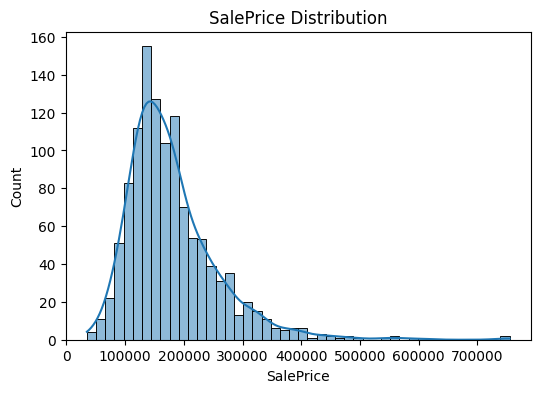

In [6]:
# SalePrice 분포 확인하기
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(train_df['SalePrice'], kde=True)
plt.title("SalePrice Distribution")
plt.show()


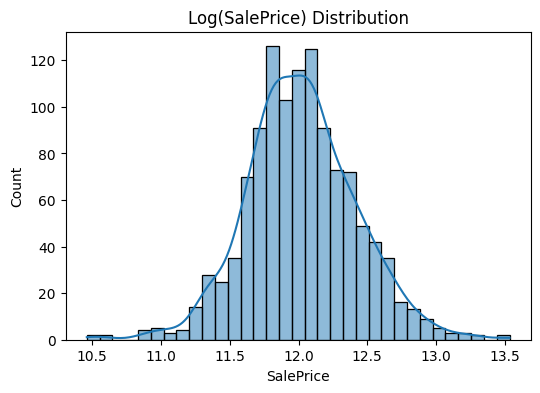

In [7]:
# SalePrice 로그 변환 분포
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(train_df['SalePrice']), kde=True)
plt.title("Log(SalePrice) Distribution")
plt.show()

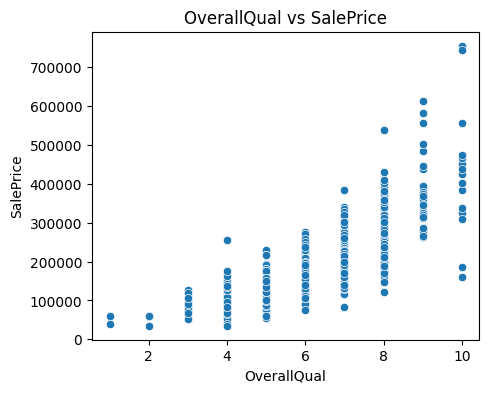

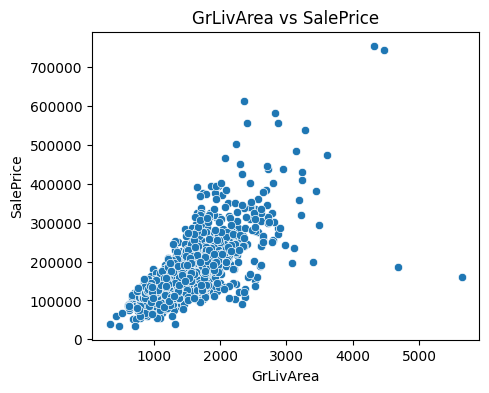

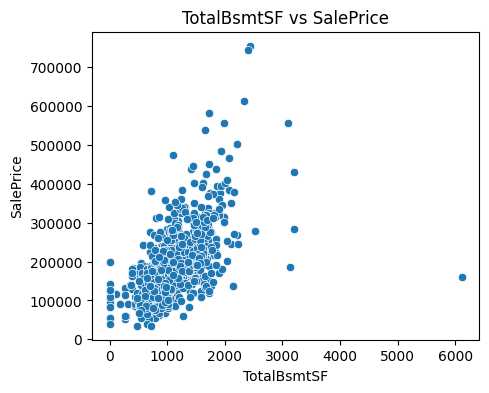

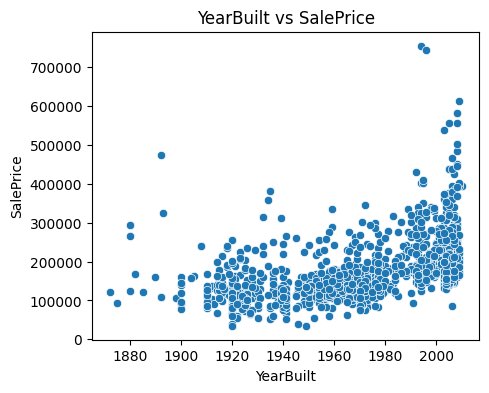

In [8]:
# 주요 변수와 관계
# 자재 및 마감 품질 종합 평가, 지상(Above grade) 생활 공간 면적, 지하실 전체 면적, 최초 건축 연도
key_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt']
for col in key_features:
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=train_df[col], y=train_df['SalePrice'])
    plt.title(f"{col} vs SalePrice")
    plt.show()

1. OverallQual 과 SalePrice 관계
- OverallQual이 올라갈수록 SalePrice이 계단식으로 증가
- 전반적인 품질 점수가 가격에 영향을 크게 미침
- 이산형 변수(순서가 있는 범주형 변수)이다
- 분산이 크다:낮은 품질은 가격분산이 적지만 높은 품질은 가격 분산이 큼 ->  품질 하나로 가격 예측 불가능 즉, 예측값 정확도가 떨어질 수 있다. -> 가격에 로그를 취하면 큰값 변동 폭 줄어 완화 가능

2. GrLivArea 과 SalePrice 관계
- 거주 면적이 커질 수록 가격 상승하는 전체적 우상향 직선 형태
- 이상치 존재: 면적이 4000 이상인데 가격이 낮은 집, 가격이 700000 이상인 비싼 집 -> 특이한 경우로 대부분의 예측에는 불리한 작용을 함 제거 여부 고민하기
- 분산이 크다 : 면적이 커질수록 가격 분산이 커진다 ->  면적 하나로는 가격 예측 불가능 -> 가격에 로그를 취하면 큰값 변동 폭 줄어 완화 가능


3. TotalBsmtSF 과 SalePrice 관계
- 지하실 면적 클수록 가격 상승 특히 0~2000 사이에서 뚜렷
- 0 근처에 점들이 모여있음-> 지하실 없는 집도 있다
- 이상치 존재: 지하실 매우 큰데 가격 낮은 집, 지하실 크기 보다 가격이 많이 높은 집-> 제거 여부 고민



4. YearBuilt 과 SalePrice 관계
- 최근에 지어진 집일수록 비쌈
- 분산이 크다: 같은 년대인데도 가격 분산이 크다 -> 건축 연도만으로는 예측 영향 주기 힘들다
- 연도 자체보다 얼마나 새집인가가 중요 -> 절대 연도에서 상대적 노후도로 변경하기



### 전처리

전처리에서 고민해야 할 것은 많습니다.

1. 결측치
2. 이상치

결측치는 처리하지 않으면 학습 자체가 불가할 수 있기 때문에, 최소한의 전처리로 결측치를 처리하겠습니다.

여러분들이라면 어떻게 결측치를 처리하면 좋을지 고민해보세요!

In [9]:
# 결측치 처리
# 수치형 → 중앙값
train_df = train_df.fillna(train_df.median(numeric_only=True))
# 범주형 → 최빈값
for col in train_df.select_dtypes(include="object"):
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

# 범주형 원 핫 인코딩
train_df = pd.get_dummies(train_df, drop_first=True)

In [10]:
# 타깃(SalePrice) 로그 변환
# y = np.log1p(train_df["SalePrice"])

In [11]:
# GrLivArea 이상치 제거
# print("제거 전:", train_df.shape)

# # 이상치 조건
# outlier_condition =train_df[(train_df["GrLivArea"] > 4000) & (train_df["SalePrice"] < 300000)]
# print("제거될 이상치 수:", outlier_condition.shape[0])

# # 이상치 제거
# train_df = train_df.drop(outlier_condition.index)
# print("제거 후:", train_df.shape)

In [12]:
# # TotalBsmtSF 이상치 제거
# print("제거 전:", train_df.shape)

# # 이상치 연고
# outliers = train_df[(train_df["TotalBsmtSF"] > 3000) & (train_df["SalePrice"] < 300000)]
# print("제거될 이상치 수:", outliers.shape[0])

# # 이상치 제거
# train_df = train_df.drop(outliers.index)
# print("제거 후:", train_df.shape)

예측값 올리기 위해 로그 변환과 이상치 제거를 제외함

### 모델 설정 및 학습

In [13]:
from sklearn.model_selection import train_test_split

X = train_df.drop("SalePrice", axis=1)
y = train_df["SalePrice"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# # 스케일링
# # 연속형 변수만 스케일링
# from sklearn.preprocessing import StandardScaler

# # 연속형 컬럼만 직접 선택
# num_cols = ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'GarageArea']

# scaler = StandardScaler()
# X[num_cols] = scaler.fit_transform(X[num_cols])

In [15]:
# 기준 모델
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [16]:
# 기준 모델 평가
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = lr_model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("Validation RMSE:", rmse)

Validation RMSE: 39135.82635710258


LinearRegression 평가
- RMSE: 26001.79319855835

In [17]:
# Ridge, Lasso  모델
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error
import numpy as np

results = {}

ridge = Ridge(
      alpha=10,
      random_state=42)

lasso = Lasso(
    alpha=0.001,
    random_state=42,
    max_iter=10000)


for name, model in [('Ridge', ridge), ('Lasso', lasso)]:
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    results[name] = rmse

results

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.141e+11, tolerance: 6.073e+08
  model = cd_fast.enet_coordinate_descent(


{'Ridge': np.float64(23545.320130731845),
 'Lasso': np.float64(42971.1551444503)}


### Ridge 평가
- RMSE: 25285.78181985977

###Lasso 평가
- RMSE: 25479.68727085874

In [76]:
# 트리 기반 모델
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=14,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# gbr = GradientBoostingRegressor(
#     n_estimators=300,
#     learning_rate=0.05,
#     max_depth=3,
#     random_state=42
# )

gbr = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    min_samples_leaf=3,
    random_state=42
)


for name, model in [('RF', rf), ('GBR', gbr)]:
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    results[name] = rmse

results

{'Ridge': np.float64(23545.320130731845),
 'Lasso': np.float64(42971.1551444503),
 'RF': np.float64(26357.506139797024),
 'GBR': np.float64(23615.58730961248)}


 ### RandomForestRegressor
 - RMSE: 24927.608148114894


 ### GradientBoostingRegressor
 - RMSE: 25146.0699223444


 gbr = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    min_samples_leaf=3,
    random_state=42
)   
- RMSE: 23615.58730961248
- 예측값: 22794.30512

n_estimators=1000,
    learning_rate=0.03,
    max_depth=2,
    subsample=0.7,
    min_samples_leaf=5,
    random_state=42

- RMSE: 25056.253998965425
- 예측값: 25463.82456





In [19]:
# 앙상블 모델 01
val_pred = (
    lr_model.predict(X_val) +
    rf.predict(X_val) +
    gbr.predict(X_val)
) / 3

ensemble_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
ensemble_rmse

np.float64(25440.51229440557)

In [20]:
# 앙상블 모델 02
val_pred = (
    ridge.predict(X_val) +
    rf.predict(X_val) +
    gbr.predict(X_val)
) / 3

ensemble_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
ensemble_rmse

np.float64(21679.702724777402)

In [21]:
# 앙상블 모델 03
val_pred = (
    lasso.predict(X_val) +
    rf.predict(X_val) +
    gbr.predict(X_val)
) / 3

ensemble_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
ensemble_rmse

np.float64(26361.34630466716)

In [22]:
# 앙상블 모델 04
val_pred = (
    lasso.predict(X_val) +
    ridge.predict(X_val) +
    gbr.predict(X_val)
) / 3

ensemble_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
ensemble_rmse

np.float64(25533.627688420645)

In [23]:
# 앙상블 모델 05
val_pred = (
    lasso.predict(X_val) +
    ridge.predict(X_val) +
    rf.predict(X_val)
) / 3

ensemble_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
ensemble_rmse

np.float64(25875.014177916593)

## 앙상블 모델 비교

- lr + rf + gbr = 22242.69765509572
- ridge + rf + gbr = 22376.926946366548
- **lasso + rf + gbr = 22227.763056042837**
- lasso + ridge+ gbr = 22728.89488296328
- lasso + ridge+ rf = 22659.06932291427


이상치 제거 제외, 로그 변환 제외 후
- lr + rf + gbr = 25440.512294405566
- **ridge + rf + gbr = 21679.702724777402**
- lasso + rf + gbr = 26361.34630466716
- lasso + ridge+ gbr = 25533.627688420645
- lasso + ridge+ rf = 25875.014177916593


In [24]:
# Ridge 규제 강도
ridge_alphas = [0.1, 1, 2, 3, 4, 5, 10, 50, 100]
ridge_results = {}

for alpha in ridge_alphas:
    model = Ridge(alpha=alpha, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    ridge_results[alpha] = rmse

for alpha, rmse in ridge_results.items():
    print(f"alpha={alpha:>6} | RMSE={rmse:.4f}")

alpha=   0.1 | RMSE=34745.6978
alpha=     1 | RMSE=27930.4346
alpha=     2 | RMSE=26415.2622
alpha=     3 | RMSE=25562.5028
alpha=     4 | RMSE=24985.5308
alpha=     5 | RMSE=24567.4900
alpha=    10 | RMSE=23545.3201
alpha=    50 | RMSE=23336.1393
alpha=   100 | RMSE=23917.9051


### Ridge 규제 강도
- alpha=   0.1 | RMSE=25454.4183
- alpha=     1 | RMSE=25053.6312
- **alpha=     2 | RMSE=25051.7593**
- alpha=     3 | RMSE=25074.8177
- alpha=     4 | RMSE=25101.7650
- alpha=     5 | RMSE=25130.3080
- alpha=    10 | RMSE=25285.7818
- alpha=    50 | RMSE=26321.9309
- alpha=   100 | RMSE=27119.7311

In [25]:
# Lasso 규제 강도
lasso_alphas = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.1]
lasso_results = {}

for alpha in lasso_alphas:
    model = Lasso(alpha=alpha, random_state=42, max_iter=10000)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    lasso_results[alpha] = rmse

for alpha, rmse in lasso_results.items():
    print(f"alpha={alpha:>6} | RMSE={rmse:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.141e+11, tolerance: 6.073e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.141e+11, tolerance: 6.073e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.141e+11, tolerance: 6.073e

alpha=0.0001 | RMSE=42814.8421
alpha=0.0005 | RMSE=42884.2749
alpha= 0.001 | RMSE=42971.1551
alpha= 0.005 | RMSE=43589.6868
alpha=  0.01 | RMSE=43790.1343
alpha=   0.1 | RMSE=43899.9699


### Lasso 규제 강도
- alpha=0.0001 | RMSE=25518.3130
- alpha=0.0005 | RMSE=25483.5897
- **alpha= 0.001 | RMSE=25453.3080**
- alpha= 0.005 | RMSE=25662.9204
- alpha=  0.01 | RMSE=25661.5799
- alpha=   0.1 | RMSE=25675.7188

## 실전에서 가장 많이 쓰는 튜닝 순서

1. learning_rate
2. n_estimators
3. max_depth
4. subsample
5. min_samples_leaf

In [67]:
# Gradient Boosting 튜닝
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np


# for lr in [0.1, 0.07, 0.05, 0.03, 0.01]:
#     model = GradientBoostingRegressor(
#         n_estimators=300,
#         learning_rate=lr,
#         max_depth=3,
#         random_state=42
#     )


# for n_estimators in [100, 300, 500, 700, 800]:
#     model = GradientBoostingRegressor(
#         n_estimators=n_estimators,
#         learning_rate=0.03,
#         max_depth=3,
#         random_state=42
#     )


# for depth in [2, 3, 4, 5, 6, 7,10,12]:
#     model = GradientBoostingRegressor(
#         n_estimators=300,
#         learning_rate=0.03,
#         max_depth=depth,
#         random_state=42
#     )

# for subsample in [0.6, 0.8, 1.0]:
#     model = GradientBoostingRegressor(
#         n_estimators=300,
#         learning_rate=0.03,
#         max_depth=3,
#         subsample=subsample,
#         random_state=42
#     )

# for leaf in [1, 2, 3, 4, 5, 10]:
#     model = GradientBoostingRegressor(
#         n_estimators=300,
#         learning_rate=0.05,
#         max_depth=3,
#         min_samples_leaf=leaf,
#         random_state=42
#     )

# for leaf in [1, 2, 3, 4, 5, 10]:
#     model = GradientBoostingRegressor(
#         n_estimators=300,
#         learning_rate=0.03,
#         max_depth=3,
#         min_samples_leaf=leaf,
#         random_state=42
#     )

# for depth in [2, 3, 4]:
#     for leaf in [2, 3, 5, 8]:
#         gbr = GradientBoostingRegressor(
#             n_estimators=1000,
#             learning_rate=0.03,
#             max_depth=depth,
#             min_samples_leaf=leaf,
#             subsample=0.8,
#             random_state=42
#         )

#     model.fit(X_train, y_train)
#     preds = model.predict(X_val)
#     rmse = np.sqrt(mean_squared_error(y_val, preds))
#     print(f"Depth={depth},n_estimators=1000, learning_rate=0.03, subsample=0.8, samples_leaf={leaf}  RMSE={rmse:.4f}")

Depth=2,n_estimators=1000, learning_rate=0.03, subsample=0.8, samples_leaf=8  RMSE=23615.5873
Depth=3,n_estimators=1000, learning_rate=0.03, subsample=0.8, samples_leaf=8  RMSE=23615.5873
Depth=4,n_estimators=1000, learning_rate=0.03, subsample=0.8, samples_leaf=8  RMSE=23615.5873



1. learning_rate 조정
- Depth=3,n_estimators=300, learning_rate=0.1, RMSE=24831.4758
- Depth=3,n_estimators=300, learning_rate=0.07, RMSE=24736.0052
- Depth=3,n_estimators=300, learning_rate=0.05, RMSE=25146.0699
- **Depth=3,n_estimators=300, learning_rate=0.03, RMSE=24385.3458**
- Depth=3,n_estimators=300, learning_rate=0.01, RMSE=24874.7662


2. n_estimators 조정
- Depth=3,n_estimators=100, learning_rate=0.03, RMSE=24779.4168
- **Depth=3,n_estimators=300, learning_rate=0.03, RMSE=24385.3458**
- Depth=3,n_estimators=500, learning_rate=0.03, RMSE=24656.2972
- Depth=3,n_estimators=700, learning_rate=0.03, RMSE=24722.4957


3. max_depth 조정
- Depth=2,n_estimators=300, learning_rate=0.03, RMSE=24988.6088
- **Depth=3,n_estimators=300, learning_rate=0.03, RMSE=24385.3458**
- Depth=4,n_estimators=300, learning_rate=0.03, RMSE=24627.8567
- Depth=5,n_estimators=300, learning_rate=0.03, RMSE=26167.2869
- Depth=6,n_estimators=300, learning_rate=0.03, RMSE=27915.2113
- Depth=7,n_estimators=300, learning_rate=0.03, RMSE=30525.1961


4. subsample 조정

- Depth=3,n_estimators=300, learning_rate=0.03, subsample=0.6, RMSE=24159.7115
- Depth=3,n_estimators=300, learning_rate=0.03, **subsample=0.8, RMSE=23543.5948**
- Depth=3,n_estimators=300, learning_rate=0.03, subsample=1.0, RMSE=25146.0699



Depth=3,n_estimators=300, learning_rate=0.03, subsample=1, RMSE=24385.3458
Depth=3,n_estimators=300, learning_rate=0.03, subsample=2, RMSE=24013.6549
Depth=3,n_estimators=300, learning_rate=0.03, subsample=3, RMSE=23287.4749
Depth=3,n_estimators=300, learning_rate=0.03, subsample=4, RMSE=22850.6826
Depth=3,n_estimators=300, learning_rate=0.03, subsample=5, RMSE=23839.0908
Depth=3,n_estimators=300, learning_rate=0.03, subsample=10, RMSE=24860.3987


5. min_samples_leaf 조정
Depth=3,n_estimators=300, learning_rate=0.03, subsample=0.8,
- min_samples_leaf=1, RMSE=25146.0699
- min_samples_leaf=2, RMSE=24011.4947
- min_samples_leaf=3, RMSE=23039.5428
- **min_samples_leaf=4, RMSE=22810.1436**
- min_samples_leaf=5, RMSE=24186.7921
- min_samples_leaf=10, RMSE=24874.9049





모든 모델 정리

1. LinearRegression
RMSE: 26001.79319855835
2. Ridge
RMSE: 25285.78181985977
- 규제 강도 alpha=     2 , RMSE=25051.7593
3. Lasso
RMSE: 25479.68727085874
- 규제 강도 alpha= 0.001 ,  RMSE=25453.3080

4. RandomForestRegressor
RMSE: 24927.608148114894

5. GradientBoostingRegressor
RMSE: 25146.0699223444

6. Gradient Boosting 튜닝
Depth=3,n_estimators=300, learning_rate=0.03, subsample=0.8, min_samples_leaf=4, RMSE=22810.1436

7. 앙상블 모델
- lr + rf + gbr = 22242.69765509572
- ridge + rf + gbr = 22376.926946366548
- **lasso + rf + gbr = 22227.763056042837**
- lasso + ridge+ gbr = 22728.89488296328
- lasso + ridge+ rf = 22659.06932291427







### 테스트 데이터 예측 및 제출

In [69]:
# 동일한 전처리
test_df = test_df.fillna(test_df.median(numeric_only=True))
for col in test_df.select_dtypes(include="object"):
    test_df[col] = test_df[col].fillna(test_df[col].mode()[0])

test_df = pd.get_dummies(test_df, drop_first=True)

# # 스케일링
# from sklearn.preprocessing import StandardScaler

# train/test 컬럼 차이 맞추기
test_df = test_df.reindex(columns=X.columns, fill_value=0)

# # 스케일링 (train에서 fit한 scaler 재사용)
# test_df[num_cols] = scaler.transform(test_df[num_cols])

# 예측
test_pred = gbr.predict(test_df)




# test_pred = (
#      0.55 * ridge.predict(test_df) +
#     0 * rf.predict(test_df) +
#     0.45 * gbr.predict(test_df)
# ) / 3

# print(lr_model.predict(test_df)[0])
# print(rf.predict(test_df)[0])
# print(gbr.predict(test_df)[0])


# test_pred = gbr.predict(test_df)
# test_pred_log = np.clip(test_pred_log, a_min=None, a_max=13.5)
# test_pred = np.expm1(test_pred_log)



로그변환, 이상치 제거, 스케일링을 다 제외하고 다시 돌렸을 때
gbr.predict 이 22916.13031

In [45]:
lr_val_pred  = lr_model.predict(X_val)
ridge_val_pred  = ridge.predict(X_val)
rf_val_pred  = rf.predict(X_val)
gbr_val_pred = gbr.predict(X_val)


In [46]:


# # 앙상블 가중치 찾기 01
# import numpy as np
# from sklearn.metrics import mean_squared_error

# best_rmse = float("inf")
# best_weights = None

# # 가중치 후보 (0.0 ~ 1.0, 0.05 단위)
# weights = np.arange(0, 1.05, 0.05)

# for w_ridge in weights:
#     for w_rf in weights:
#         w_gbr = 1 - w_ridge - w_rf
#         if w_gbr < 0:
#             continue

#         val_pred = (
#             w_ridge  * ridge_val_pred +
#             w_rf  * rf_val_pred +
#             w_gbr * gbr_val_pred
#         )

#         rmse = np.sqrt(mean_squared_error(y_val, val_pred))

#         if rmse < best_rmse:
#             best_rmse = rmse
#             best_weights = (w_ridge, w_rf, w_gbr)

# best_weights, best_rmse

((np.float64(0.5), np.float64(0.0), np.float64(0.5)),
 np.float64(21050.959696000406))

((np.float64(0.05), np.float64(0.0), np.float64(0.95)),
 np.float64(23451.996050206362))

In [48]:
# # 앙상블 가중치 찾기 02
# high_idx = y_val > np.percentile(y_val, 75)  # 상위 25%

# best_rmse = float("inf")
# best_weights = None

# for w_ridge in weights:
#     for w_rf in weights:
#         w_gbr = 1 - w_ridge - w_rf
#         if w_gbr < 0:
#             continue

#         val_pred = (
#             w_ridge  * ridge_val_pred +
#             w_rf  * rf_val_pred +
#             w_gbr * gbr_val_pred
#         )

#         rmse = np.sqrt(mean_squared_error(
#             y_val[high_idx],
#             val_pred[high_idx]
#         ))

#         if rmse < best_rmse:
#             best_rmse = rmse
#             best_weights = (w_ridge, w_rf, w_gbr)

# best_weights, best_rmse

((np.float64(0.55), np.float64(0.0), np.float64(0.44999999999999996)),
 np.float64(31634.136075564536))

1. 타깃 로그 변환 후 테스트에서 예측값을 되돌리지 않았음
2. 예측값 되돌리면서 무한대가 생김
test_pred_log = (
    0.1 * lasso.predict(test_df) +
    0.45 * rf.predict(test_df) +
    0.45 * gbr.predict(test_df)
)

test_pred_log = np.clip(test_pred_log, a_min=None, a_max=13.5)
test_pred = np.expm1(test_pred_log)





In [71]:
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_pred
})
submission.to_csv("submission.csv", index=False)